# Assignment 4

Deadline: 22.04.2026 12:00 CET

- Marcel Blagotinšek, 25-744-202, marcel.blagotinsek@uzh.ch
- Lyuben Baltadzhiev, 25-739-046, lyubenmiroslavov.baltadzhiev@uzh.ch
- Michal Andrzejewski, 25-737-503, michalmaria.andrzejewski@uzh.ch
- Lorenzo Pagliani, 25-741-430, lorenzo.pagliani@uzh.ch
- Lorenzo Barbero, 25-743-709, lorenzo.barbero@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [35]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [ ]:
PATH_TO_DATA = os.path.join(project_root, 'qpmwp-course', 'data')

In [37]:

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}/market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}/jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [38]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [39]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)

        self.covmat = np.asarray(covmat, dtype=float)
        self.mu = np.asarray(mu, dtype=float).reshape(-1)

        self.objective = Objective(
            q=-self.mu,
            P=2 * self.params['risk_aversion'] * self.covmat,
        )
        return None

    def solve(self) -> None:
        lam = float(self.params.get('risk_aversion', 1.0))
        max_iter = int(self.params.get('max_iter', 10))
        tol = float(self.params.get('tol', 1e-8))

        for _ in range(max_iter):
            self.objective = Objective(
                q=-self.mu,
                P=2 * lam * self.covmat,
            )
            super().solve()

            w = (
                pd.Series(self.results['weights'])
                .reindex(self.constraints.ids)
                .to_numpy(dtype=float)
            )

            denom = 2 * (w @ self.covmat @ w)
            if denom <= 0:
                break

            lam_new = (self.mu @ w) / denom
            if not np.isfinite(lam_new) or lam_new <= 0:
                break

            if abs(lam_new - lam) <= tol * max(1.0, abs(lam)):
                lam = lam_new
                break

            lam = lam_new

        self.params['risk_aversion'] = lam
        self.objective = Objective(
            q=-self.mu,
            P=2 * lam * self.covmat,
        )
        super().solve()
        self.results['risk_aversion'] = lam
        return None
    

### Remark on the code

The maximum Sharpe ratio problem is
$$
\max_w \frac{\mu^\top w}{\sqrt{w^\top \Sigma w}}.
$$

This is not a quadratic objective, so we solve it with our mean-variance class which we used to solve problems of the form
$$
\min_w \left(-\mu^\top w + \lambda w^\top \Sigma w\right).
$$

In `set_objective`, we estimate $\mu$ and $\Sigma$ from the return series and write the problem in standard quadratic form
$$
\min_w \frac12 w^\top P w + q^\top w,
\qquad
P = 2\lambda \Sigma,\quad q = -\mu.
$$

In `solve`, we start from an initial value of $\lambda$, solve the corresponding quadratic problem, extract the portfolio weights $w$, and update $\lambda$ by
$$
\lambda_{\text{new}} = \frac{\mu^\top w}{2\, w^\top \Sigma w}.
$$

This update comes from the first-order condition
$$
-\mu + 2\lambda \Sigma w = 0.
$$

The iteration stops if the denominator is not positive, if the new $\lambda$ is invalid, or if the change in $\lambda$ is smaller than the tolerance. After that, we solve the problem one last time with the final value of $\lambda$ and store it in `self.results['risk_aversion']`.

In shorte: estimate $\mu$ and $\Sigma$, solve the quadratic problem, update $\lambda$, and repeat until $\lambda$ stabilizes.

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

### Theoretical justification - i dont know how to conclude

For each $\lambda>0$, define
$$
w(\lambda)=\arg\min_{w\in\mathcal C}\left(-\mu^\top w+\lambda,w^\top\Sigma w\right),
$$
and
$$
T(\lambda)=\frac{\mu^\top w(\lambda)}{2w(\lambda)^\top\Sigma w(\lambda)}.
$$

Since $\Sigma\succ0$, the objective is strongly convex in $w$, so for every $\lambda>0$ the minimizer $w(\lambda)$ is unique. Therefore the iteration in part 1.a can be written as
$$
\lambda_{k+1}=T(\lambda_k).
$$

To prove convergence, two things must hold for the map $T$, with $\mu$ and $\Sigma$ fixed at one rebalance date.

First, there must be an interval $I\subset(0,\infty)$ such that
$$
T(I)\subseteq I.
$$

Second, the map must be contractive on that interval:
$$
\sup_{\lambda\in I}|T'(\lambda)|<1.
$$

If both conditions hold, then $T$ is a contraction on $I$. By the Banach fixed-point theorem, $T$ has a unique fixed point $\lambda^\star\in I$, and the iteration converges to $\lambda^\star$ for every starting value $\lambda_0\in I$.

So the algorithm can be justified as a fixed-point iteration. Convergence follows once the update map is contractive on an interval containing the iterates - somehow verify or change the theoretical justification...


In [40]:
# bs.optimization = MaxSharpe(
#     covariance=Covariance(method='pearson'),
#     expected_return=ExpectedReturn(method='geometric'),
#     solver_name='cvxopt',  # <change this to your preferred solver>
#     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
# )
# bs.prepare_rebalancing(rebdates[-1])
# bs.optimization.set_objective(bs.optimization_data)
# bs.optimization.solve()
#
# bs.optimization.results

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=1.0,
    max_iter=10,
    tol=1e-8,
)

rebdate_check = rebdates[-1]
bs.prepare_rebalancing(rebdate_check)
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

ids = bs.optimization.constraints.ids
mu = pd.Series(bs.optimization.mu, index=ids)
covmat = pd.DataFrame(bs.optimization.covmat, index=ids, columns=ids)

w_iter = pd.Series(bs.optimization.results['weights']).reindex(ids)
ret_iter = mu @ w_iter
vol_iter = np.sqrt(w_iter @ covmat @ w_iter)
sr_iter = ret_iter / vol_iter
lam_iter = float(bs.optimization.results['risk_aversion'])

lambda_grid = np.logspace(-2, 3, 100)
rows = []

for lam in lambda_grid:
    opt_tmp = MeanVariance(
        constraints=copy.deepcopy(bs.optimization.constraints),
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        risk_aversion=float(lam),
    )
    opt_tmp.set_objective(bs.optimization_data)
    opt_tmp.solve()

    w_tmp = pd.Series(opt_tmp.results['weights']).reindex(ids)
    ret_tmp = mu @ w_tmp
    vol_tmp = np.sqrt(w_tmp @ covmat @ w_tmp)
    sr_tmp = ret_tmp / vol_tmp if vol_tmp > 0 else np.nan

    rows.append({
        'lambda': lam,
        'expected_return': ret_tmp,
        'volatility': vol_tmp,
        'sharpe': sr_tmp,
    })

df_grid = pd.DataFrame(rows)
best_grid = df_grid.loc[df_grid['sharpe'].idxmax()].copy()

opt_best = MeanVariance(
    constraints=copy.deepcopy(bs.optimization.constraints),
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=float(best_grid['lambda']),
)
opt_best.set_objective(bs.optimization_data)
opt_best.solve()

w_grid = pd.Series(opt_best.results['weights']).reindex(ids)

comparison = pd.DataFrame([
    {
        'method': 'iterative',
        'lambda': lam_iter,
        'expected_return': ret_iter,
        'volatility': vol_iter,
        'sharpe': sr_iter,
    },
    {
        'method': 'best_grid',
        'lambda': best_grid['lambda'],
        'expected_return': best_grid['expected_return'],
        'volatility': best_grid['volatility'],
        'sharpe': best_grid['sharpe'],
    }
]).round(6)

weight_compare = pd.concat(
    [w_iter.rename('iterative'), w_grid.rename('best_grid')],
    axis=1
)

weights = (
    weight_compare.loc[(w_iter - w_grid).abs().sort_values(ascending=False).index]
    .round(6)
)

print("Comparison of iterative solution and best grid solution")
display(comparison)

print("Portfolio weights comparison")
display(weights)

Comparison of iterative solution and best grid solution


,method,lambda,expected_return,volatility,sharpe
0,iterative,2.975019,0.000679,0.010686,0.063581
1,best_grid,2.983647,0.000679,0.010684,0.063581


Portfolio weights comparison


,iterative,best_grid
192,0.013621,0.013373
177,0.019176,0.019388
231,0.048970,0.049070
170,0.018192,0.018137
129,0.099977,0.099971
...,...,...
63,0.000000,0.000000
254,0.000000,0.000000
297,0.000000,0.000000
291,0.000000,0.000000


### Empirical justification

For one fixed rebalance date, $\mu$, $\Sigma$, and the constraint set are fixed. We compared the iterative `MaxSharpe` solution with the best portfolio obtained from a fine grid of mean-variance problems over different values of $\lambda$.

The table shows that the iterative solution and the best grid solution have the same expected return, volatility, and Sharpe ratio up to numerical precision. The printed portfolio weights are also almost the same. This shows that, for this instance, the iterative algorithm converged to the same solution as the best portfolio found over the grid.


## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [ ]:
risk_aversion_ms = float(bs.optimization.results['risk_aversion'])
return_series_full = bs.data.get_return_series(weekdays_only=False)

def annual_turnover(bt, return_series):
    to = bt.strategy.turnover(return_series=return_series)
    return to.iloc[1:].mean() * (12 / n_month)

rebdates_cal = rebdates[:12]
tau_grid = [0.00008, 0.00009, 0.00010, 0.00011, 0.00012, 0.00013, 0.00014, 0.00015]

old_rebdates = list(bs.settings['rebdates'])
old_quiet = bs.settings.get('quiet', False)

rows = []
for tau in tau_grid:
    bs.settings['rebdates'] = rebdates_cal
    bs.settings['quiet'] = True

    bs.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        risk_aversion=risk_aversion_ms,
        max_iter=10,
        tol=1e-8,
        turnover_penalty=tau,
    )

    bt_tmp = Backtest()
    bt_tmp.run(bs=bs)

    ann_to = annual_turnover(bt_tmp, return_series_full)

    rows.append({
        'turnover_penalty': tau,
        'annual_turnover': ann_to,
        'annual_turnover_pct': 100 * ann_to,
        'distance_to_target': abs(ann_to - 1.0),
    })

calibration = pd.DataFrame(rows).sort_values('turnover_penalty')
display(calibration.round(6))

turnover_penalty_ms = float(
    calibration.loc[calibration['distance_to_target'].idxmin(), 'turnover_penalty']
)

bs.settings['rebdates'] = old_rebdates
bs.settings['quiet'] = True

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=risk_aversion_ms,
    max_iter=10,
    tol=1e-8,
    turnover_penalty=turnover_penalty_ms,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

turnover_ms = bt_ms.strategy.turnover(return_series=return_series_full)
annual_turnover_ms = turnover_ms.iloc[1:].mean() * (12 / n_month)

print(f"Chosen turnover penalty: {turnover_penalty_ms:.8f}")
print(f"Annual turnover on full backtest: {100 * annual_turnover_ms:.2f}%")

,turnover_penalty,annual_turnover,annual_turnover_pct,distance_to_target
0,0.0001,1.0735,107.3487,0.0735
1,0.0001,1.0566,105.6580,0.0566
2,0.0001,1.0406,104.0611,0.0406
3,0.0001,1.0207,102.0742,0.0207
4,0.0001,1.0075,100.7480,0.0075
5,0.0001,0.9928,99.2773,0.0072
6,0.0001,0.9666,96.6567,0.0334
7,0.0001,0.9323,93.2331,0.0677


Chosen turnover penalty: 0.000130
Annual turnover on full backtest: 88.32%


In [59]:
display(calibration.round(6))

,turnover_penalty,annual_turnover,annual_turnover_pct,distance_to_target
0,0.00008,1.073487,107.348674,0.073487
1,0.00009,1.056580,105.658009,0.056580
2,0.00010,1.040611,104.061131,0.040611
3,0.00011,1.020742,102.074238,0.020742
4,0.00012,1.007480,100.747969,0.007480
5,0.00013,0.992773,99.277271,0.007227
6,0.00014,0.966567,96.656701,0.033433
7,0.00015,0.932331,93.233141,0.067669


In [46]:
# Refine on the full rebalance period around the known good region

tau_grid_full = [0.00007, 0.00008, 0.00009, 0.00010, 0.00011, 0.000115, 0.00012, 0.000125, 0.00013]

old_rebdates = list(bs.settings['rebdates'])
old_quiet = bs.settings.get('quiet', False)

rows_full = []
for tau in tau_grid_full:
    bs.settings['rebdates'] = rebdates
    bs.settings['quiet'] = True

    bs.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        risk_aversion=risk_aversion_ms,
        max_iter=10,
        tol=1e-8,
        turnover_penalty=tau,
    )

    bt_tmp = Backtest()
    bt_tmp.run(bs=bs)

    ann_to = annual_turnover(bt_tmp, return_series_full)

    print(
        f"tau = {tau:.8f} | annual turnover = {100 * ann_to:.2f}% | "
        f"distance to 100% = {100 * abs(ann_to - 1.0):.2f}%"
    )

    rows_full.append({
        'turnover_penalty': tau,
        'annual_turnover': ann_to,
        'annual_turnover_pct': 100 * ann_to,
        'distance_to_target': abs(ann_to - 1.0),
    })

bs.settings['rebdates'] = old_rebdates
bs.settings['quiet'] = old_quiet

calibration_full = pd.DataFrame(rows_full).sort_values('turnover_penalty')
display(calibration_full.round(6))

turnover_penalty_ms = float(
    calibration_full.loc[calibration_full['distance_to_target'].idxmin(), 'turnover_penalty']
)

bs.settings['rebdates'] = rebdates
bs.settings['quiet'] = True

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=risk_aversion_ms,
    max_iter=10,
    tol=1e-8,
    turnover_penalty=turnover_penalty_ms,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

turnover_ms = bt_ms.strategy.turnover(return_series=return_series_full)
annual_turnover_ms = turnover_ms.iloc[1:].mean() * (12 / n_month)

print(f"Refined turnover penalty: {turnover_penalty_ms:.8f}")
print(f"Annual turnover on full backtest: {100 * annual_turnover_ms:.2f}%")

tau = 0.00007000 | annual turnover = 111.83% | distance to 100% = 11.83%
tau = 0.00008000 | annual turnover = 106.34% | distance to 100% = 6.34%
tau = 0.00009000 | annual turnover = 102.24% | distance to 100% = 2.24%
tau = 0.00010000 | annual turnover = 98.40% | distance to 100% = 1.60%
tau = 0.00011000 | annual turnover = 94.83% | distance to 100% = 5.17%
tau = 0.00011500 | annual turnover = 93.15% | distance to 100% = 6.85%
tau = 0.00012000 | annual turnover = 91.48% | distance to 100% = 8.52%
tau = 0.00012500 | annual turnover = 89.80% | distance to 100% = 10.20%
tau = 0.00013000 | annual turnover = 88.32% | distance to 100% = 11.68%


,turnover_penalty,annual_turnover,annual_turnover_pct,distance_to_target
0,0.000070,1.118341,111.834146,0.118341
1,0.000080,1.063367,106.336745,0.063367
2,0.000090,1.022390,102.239047,0.022390
3,0.000100,0.984020,98.402041,0.015980
4,0.000110,0.948277,94.827711,0.051723
5,0.000115,0.931531,93.153107,0.068469
6,0.000120,0.914793,91.479340,0.085207
7,0.000125,0.897981,89.798065,0.102019
8,0.000130,0.883245,88.324469,0.116755


Refined turnover penalty: 0.00010000
Annual turnover on full backtest: 98.40%


In [47]:
# Refine on the full rebalance period around the known good region

tau_grid_full = [0.000092, 0.000094, 0.000096, 0.000098]

old_rebdates = list(bs.settings['rebdates'])
old_quiet = bs.settings.get('quiet', False)

rows_full = []
for tau in tau_grid_full:
    bs.settings['rebdates'] = rebdates
    bs.settings['quiet'] = True

    bs.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        risk_aversion=risk_aversion_ms,
        max_iter=10,
        tol=1e-8,
        turnover_penalty=tau,
    )

    bt_tmp = Backtest()
    bt_tmp.run(bs=bs)

    ann_to = annual_turnover(bt_tmp, return_series_full)

    print(
        f"tau = {tau:.8f} | annual turnover = {100 * ann_to:.2f}% | "
        f"distance to 100% = {100 * abs(ann_to - 1.0):.2f}%"
    )

    rows_full.append({
        'turnover_penalty': tau,
        'annual_turnover': ann_to,
        'annual_turnover_pct': 100 * ann_to,
        'distance_to_target': abs(ann_to - 1.0),
    })

bs.settings['rebdates'] = old_rebdates
bs.settings['quiet'] = old_quiet

calibration_full = pd.DataFrame(rows_full).sort_values('turnover_penalty')
display(calibration_full.round(6))

turnover_penalty_ms = float(
    calibration_full.loc[calibration_full['distance_to_target'].idxmin(), 'turnover_penalty']
)

bs.settings['rebdates'] = rebdates
bs.settings['quiet'] = True

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=risk_aversion_ms,
    max_iter=10,
    tol=1e-8,
    turnover_penalty=turnover_penalty_ms,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

turnover_ms = bt_ms.strategy.turnover(return_series=return_series_full)
annual_turnover_ms = turnover_ms.iloc[1:].mean() * (12 / n_month)

print(f"Refined turnover penalty: {turnover_penalty_ms:.8f}")
print(f"Annual turnover on full backtest: {100 * annual_turnover_ms:.2f}%")

tau = 0.00009200 | annual turnover = 101.41% | distance to 100% = 1.41%
tau = 0.00009400 | annual turnover = 100.64% | distance to 100% = 0.64%
tau = 0.00009600 | annual turnover = 99.97% | distance to 100% = 0.03%
tau = 0.00009800 | annual turnover = 99.24% | distance to 100% = 0.76%


,turnover_penalty,annual_turnover,annual_turnover_pct,distance_to_target
0,0.000092,1.014058,101.405789,0.014058
1,0.000094,1.006394,100.639379,0.006394
2,0.000096,0.999680,99.968003,0.000320
3,0.000098,0.992417,99.241685,0.007583


Refined turnover penalty: 0.00009600
Annual turnover on full backtest: 99.97%


### Remark

We first calibrated the turnover penalty on a smaller set of rebalance dates, following the hint, in order to identify a reasonable range of values. Since the assignment target concerns the turnover of the final backtest, we then checked the best candidate values on the full rebalance period and selected the one for which the annualized turnover of the full backtest is closest to 100\%.

From the final refinement on the full backtest, the selected value is
$$
\tau = 0.000096,
$$
which gives annual turnover of about
$$
99.97\%.
$$
This is closest to the 100\% target among the tested candidates.

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


<Axes: title={'center': 'Cumulative returns: MaxSharpe vs SPI'}>

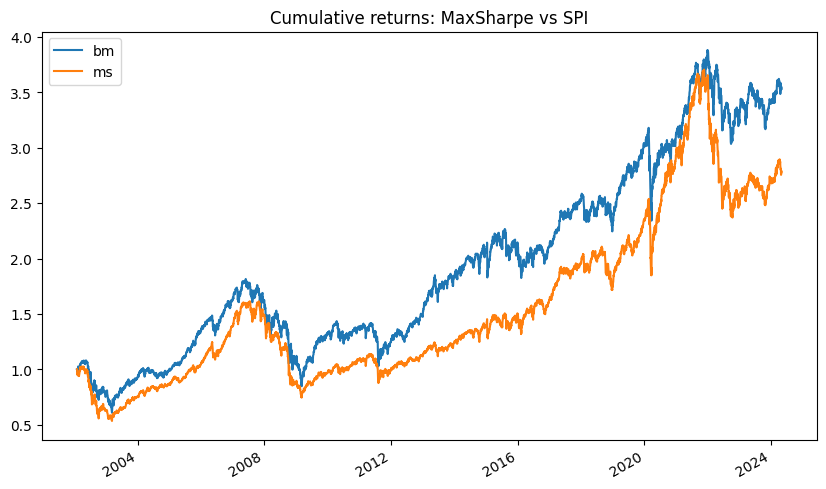

In [58]:
fixed_costs = 0.01  
variable_costs = 0.003 
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

# Plot the cumulative returns of the strategy and the benchmark
cumret = (1 + sim).cumprod()

cumret.plot(figsize=(10, 6), title='Cumulative returns: MaxSharpe vs SPI')


<Axes: title={'center': 'Turnover'}>

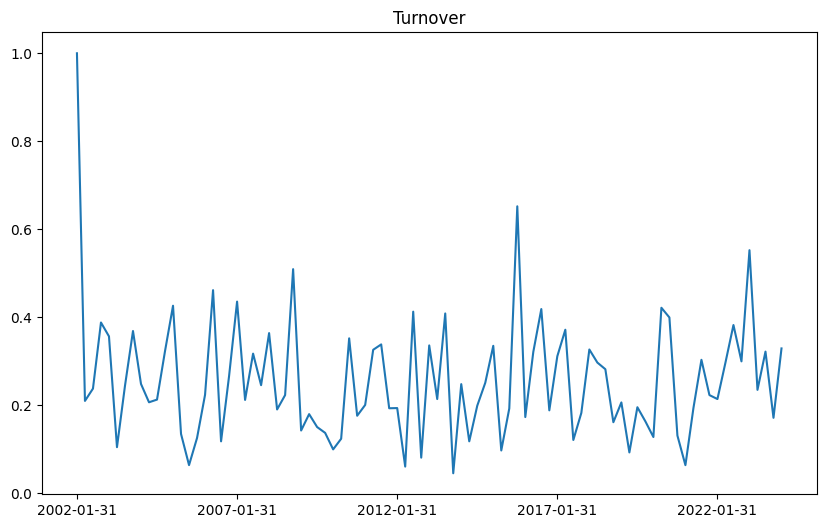

In [52]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [ ]:
# Annualized turnover per annum (pa) in percentage
to_pa = to_ms.iloc[1:].mean() * (12 / n_month) * 100 
print(f"The annualized turnover is: {to_pa:.2f}%")

The annualized turnover is: 99.97%


In [57]:
# Descriptive statistics

r_ms = sim['ms'].dropna()
wealth_ms = (1 + r_ms).cumprod()
drawdown_ms = wealth_ms / wealth_ms.cummax() - 1
ann_return_ms = (1 + r_ms).prod() ** (252 / len(r_ms)) - 1
ann_vol_ms = r_ms.std() * np.sqrt(252)
sharpe_ms = ann_return_ms / ann_vol_ms
max_dd_ms = drawdown_ms.min()
total_return_ms = wealth_ms.iloc[-1] - 1

r_bm = sim['bm'].dropna()
wealth_bm = (1 + r_bm).cumprod()
drawdown_bm = wealth_bm / wealth_bm.cummax() - 1
ann_return_bm = (1 + r_bm).prod() ** (252 / len(r_bm)) - 1
ann_vol_bm = r_bm.std() * np.sqrt(252)
sharpe_bm = ann_return_bm / ann_vol_bm
max_dd_bm = drawdown_bm.min()
total_return_bm = wealth_bm.iloc[-1] - 1

stats = pd.DataFrame({
    'MaxSharpe': [
        total_return_ms,
        ann_return_ms,
        ann_vol_ms,
        sharpe_ms,
        max_dd_ms,
    ],
    'SPI': [
        total_return_bm,
        ann_return_bm,
        ann_vol_bm,
        sharpe_bm,
        max_dd_bm,
    ]
}, index=[
    'Total return',
    'Annualized return',
    'Annualized volatility',
    'Sharpe ratio',
    'Max drawdown',
])

display(stats.round(4))

,MaxSharpe,SPI
Total return,1.7777,2.5325
Annualized return,0.0448,0.0556
Annualized volatility,0.1446,0.1647
Sharpe ratio,0.3099,0.3379
Max drawdown,-0.5370,-0.5325
